In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader, ConcatDataset
import math
import scipy.special
import random as rd
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from sgr_utils import *

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


### Loading cifar-10 dataset

In [2]:
# Define transforms for CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]) # imageNet stats by rgb channel

# Load full training set (50,000 samples)
full_train_dataset = datasets.CIFAR10(root="C:/Users/ejeme/Documents/python_repos/CIFAR/cifar_data", train=True, transform=transform, download=True)
# Load official test set (10,000 samples)
official_test_dataset = datasets.CIFAR10(root="C:/Users/ejeme/Documents/python_repos/CIFAR/cifar_data", train=False, transform=transform, download=True)
# Split 50,000 into 30k train and 20k extra test
train_size = 30000
extra_test_size = len(full_train_dataset) - train_size  # 20000
# Use a fixed seed for reproducibility
generator = torch.Generator().manual_seed(42)
train_dataset, extra_test_dataset = random_split(full_train_dataset, [train_size, extra_test_size], generator=generator)
# Concatenate the 20k extra test samples with the official test set
combined_test_dataset = ConcatDataset([extra_test_dataset, official_test_dataset])
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True)
test_loader = DataLoader(combined_test_dataset, batch_size=6, shuffle=False)

### Training vgg16 for cifar-10 multiclass classification task

In [3]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load Pretrained VGG16 Model
vgg16 = models.vgg16(weights=VGG16_Weights.DEFAULT)
# Modify classifier for CIFAR-10 (10 classes)
vgg16.classifier[6] = nn.Linear(4096, 10)
# Move model to GPU if available
vgg16 = vgg16.to(device)

In [5]:
# Define Loss, Optimizer and lr scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg16.parameters(), lr=1e-4)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=0)

# Training Loop
num_epochs = 10
for epoch in range(num_epochs):
    vgg16.train()
    running_loss = 0
    correct = 0
    total = 0

    print('TRAINING EPOCH', epoch)
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vgg16(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
            
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    print(f"Train Accuracy: {100 * correct / total:.2f}%")

    # Evaluate Model at the end of current epoch
    vgg16.eval()
    correct = 0
    total = 0
    print('TESTING')
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vgg16(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    print(f"Validation Accuracy: {100 * correct / total:.2f}%")
    scheduler.step(correct)

    torch.save(vgg16.state_dict(), "C:/Users/ejeme/Documents/python_repos/CIFAR/vgg16_cifar10_epoch"+str(epoch)+".pth")

TRAINING EPOCH 0


100%|██████████| 5000/5000 [09:27<00:00,  8.81it/s]


Epoch [1/10], Loss: 0.8057
Train Accuracy: 72.53%
TESTING
Validation Accuracy: 83.34%
TRAINING EPOCH 1


100%|██████████| 5000/5000 [09:26<00:00,  8.83it/s]


Epoch [2/10], Loss: 0.4612
Train Accuracy: 84.78%
TESTING
Validation Accuracy: 84.69%
TRAINING EPOCH 2


100%|██████████| 5000/5000 [09:24<00:00,  8.85it/s]


Epoch [3/10], Loss: 0.3401
Train Accuracy: 88.73%
TESTING
Validation Accuracy: 86.00%
TRAINING EPOCH 3


  9%|▉         | 470/5000 [00:53<08:34,  8.81it/s]


KeyboardInterrupt: 

Epoch 1 with 85% train and test accuracy is fine

### Retrieving Softmax Response, Predicted class and True class for all samples in train and in test sets

In [4]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load Pretrained VGG16 Model
vgg16 = models.vgg16(weights=VGG16_Weights.DEFAULT)
# Modify classifier for CIFAR-10 (10 classes)
vgg16.classifier[6] = nn.Linear(4096, 10)
# Move model to GPU if available
vgg16 = vgg16.to(device)

checkpoint = torch.load("C:/Users/ejeme/Documents/python_repos/CIFAR/vgg16_cifar10_epoch1.pth")
vgg16.load_state_dict(checkpoint)

<All keys matched successfully>

In [5]:
sgr_dico = prepare_sgr_dico(test_loader, model = vgg16, device = device, T = 10)
sgr_set = pd.DataFrame(sgr_dico)
pickle.dump(sgr_set, open('sgr_set','wb'))

100%|██████████| 5000/5000 [02:20<00:00, 35.62it/s]


In [6]:
sgr_set.sort_values('SR')

,y_true,y_pred,SR
16856,2.0,3.0,0.104304
12898,8.0,9.0,0.105795
5497,7.0,3.0,0.106319
27709,3.0,7.0,0.107196
1420,7.0,4.0,0.107403
...,...,...,...
20871,1.0,1.0,0.950530
240,1.0,1.0,0.955238
17117,5.0,5.0,0.957677
27876,1.0,1.0,0.960892


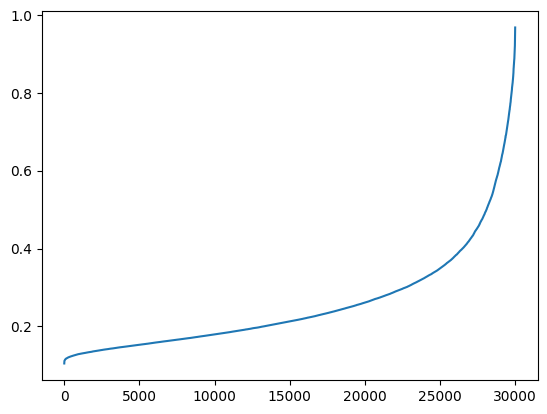

In [7]:
plt.plot(list(sgr_set.sort_values('SR').SR))
plt.show()